In [43]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

In [44]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[3].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

In [45]:
x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

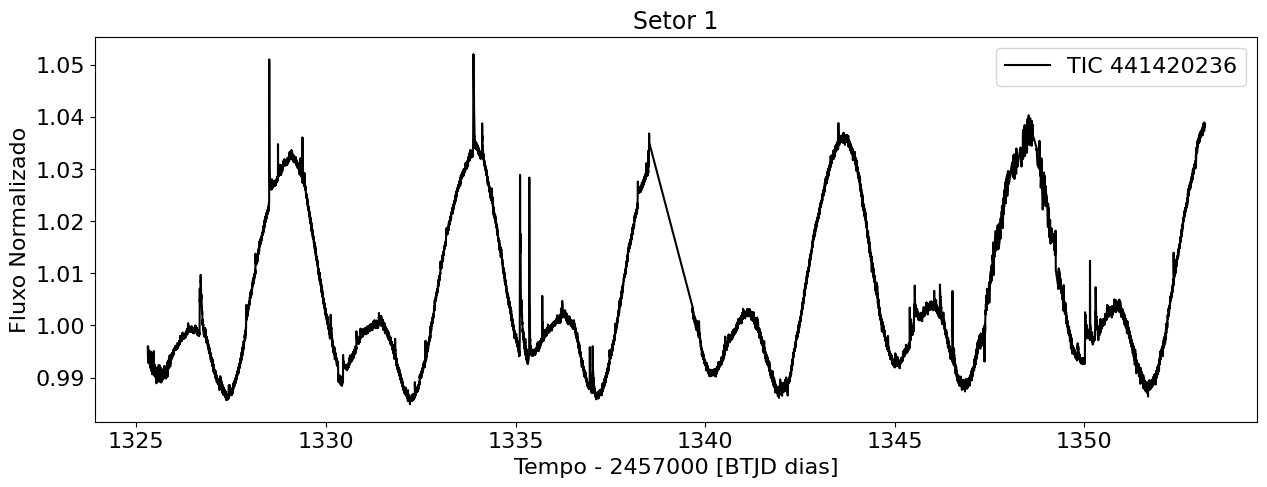

In [46]:
#%matplotlib notebook
plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 1').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()

In [55]:
######### FLATTEN NOVO #########################

vetores = [
    [1326.6711, 1326.7794],
    [1327.8929, 1327.9763],
    [1329.3756, 1329.4123],
    [1330.1210, 1330.1377],
    [1330.4496, 1330.5464],
    [1331.8210, 1331.8574],
    [1333.8797, 1333.9809],
    [1334.1134, 1334.1507],
    [1335.1052, 1335.2524],
    [1335.3517, 1335.4232],
    [1335.7022, 1335.7252],
    [1336.2287, 1336.2454],
    [1336.9519, 1336.9890],
    [1337.0179, 1337.0633],
    [1338.2201, 1338.2396],
    [1338.4973, 1338.5127],
    [1343.5045, 1343.5218],
    [1345.3914, 1345.4122],
    [1345.3918, 1345.4119],
    [1345.5044, 1345.5562],
    [1346.1841, 1346.2377],
    [1346.5162, 1346.5464],
    [1350.0068, 1350.0502],
    [1350.1441, 1350.3345],
    [1350.2795, 1350.3247],
    [1330.3039, 1330.4724],
    [1347.3173, 1347.3250],
    [1342.2240, 1342.2398],
    [1352.3514, 1352.3619],
    [1349.4516, 1349.4714],
    [1349.8142, 1349.8432],
    [1345.3926, 1345.4123],
    [1350.2720, 1350.3608],
    [1350.0112, 1350.4109],
    [1349.2727, 1349.3229],
]

vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)


flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=False, break_tolerance=100, niters=3, sigma=2.5, mask=mascara)
x_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)
yerr_detrend= np.ascontiguousarray(flcd.flux_err, dtype=np.float64)


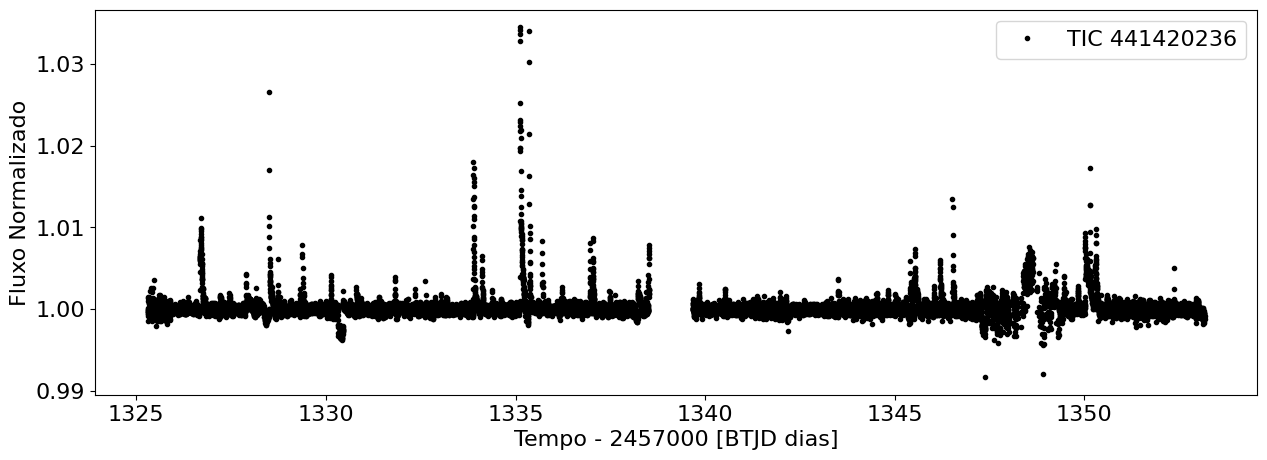

In [56]:


fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x_detrend,y_detrend,'k.',label = 'TIC 441420236',)
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

In [57]:
flcd.to_fits(path='demo-lightcurve_new.fits', overwrite=True)

In [58]:
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('demo-lightcurve_new.fits')
type(hdu)

astropy.io.fits.hdu.hdulist.HDUList

In [59]:
from astropy.table import Table
dat = Table.read('demo-lightcurve_new.fits', format='fits')
df = dat.to_pandas()

In [60]:
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64
TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64


In [61]:
%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


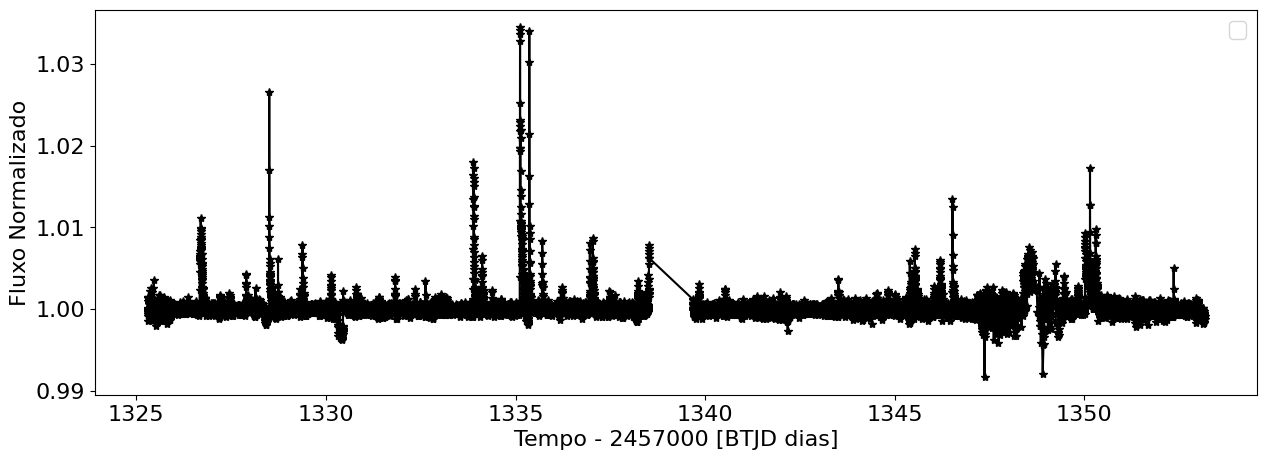

In [62]:

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(time,flux, 'k*-')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

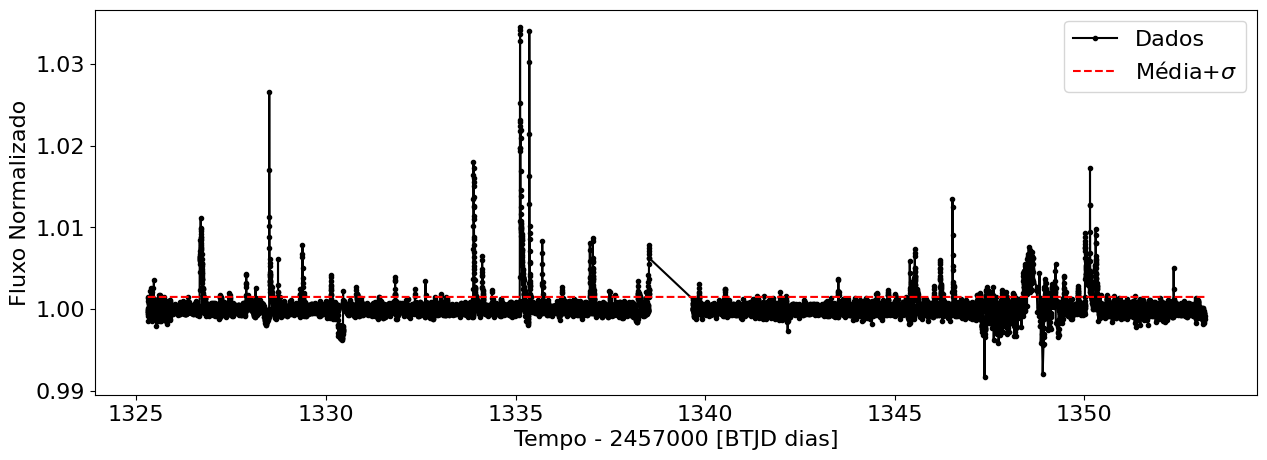

In [63]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()


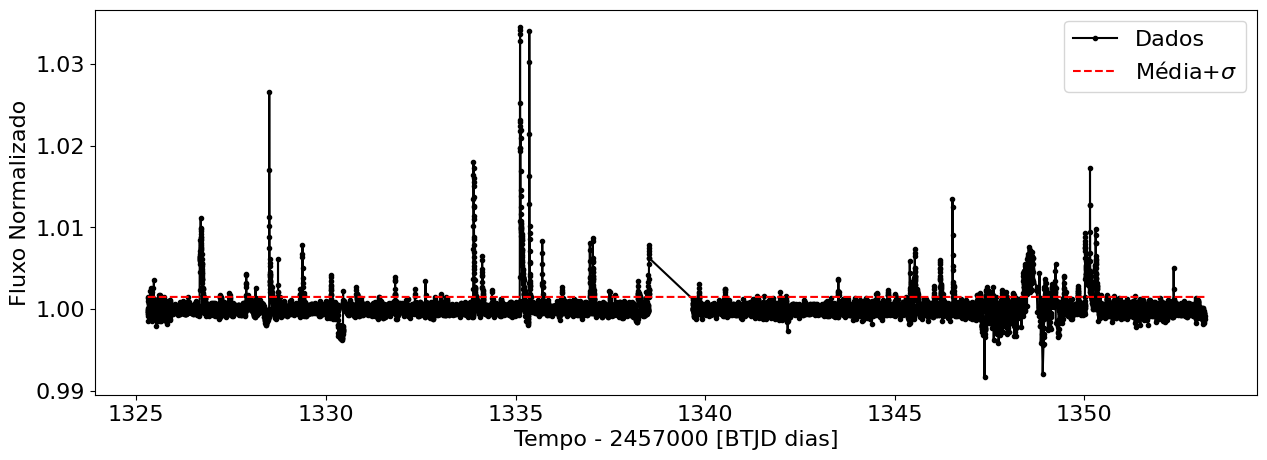

In [39]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()

[1.0000391 1.0068641 1.0083354 1.0055282 1.0042555 1.0029227 1.0032613
 1.0026757 1.0032771 1.00272   1.0018846 1.0015638 1.0007502 1.0006794
 1.0004793 1.0007222 1.0001638 1.0008097 1.0005364 1.0000305 1.0004104
 1.0001544 1.0006232 0.9996786 1.0000443 1.0002273]
[1335.70134469 1335.70273356 1335.70412243 1335.7055113  1335.70690017
 1335.70828904 1335.70967791 1335.71106678 1335.71245565 1335.71384452
 1335.71523339 1335.71662226 1335.71801113 1335.7194     1335.72078887
 1335.72217774 1335.72356661 1335.72495548 1335.72634436 1335.72773323
 1335.7291221  1335.73051097 1335.73189984 1335.73328871 1335.73467758
 1335.73606645]


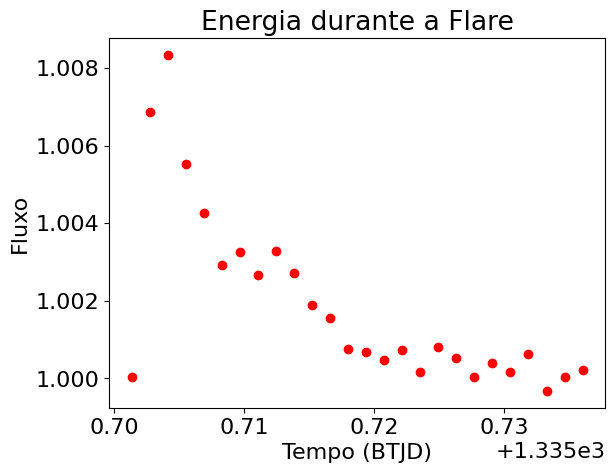

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de início e término da flare (substitua pelos valores desejados)
start_input = 1335.7011
stop_input = 1335.7372

def ener_flare(start, stop, time, flux):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i] >= start and time[i] <= stop:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare

# Chamada da função ener_flare com os dados de exemplo
flux_flare, tempo_flare = ener_flare(start_input, stop_input, time, flux)
print(flux_flare)
print(tempo_flare)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare, flux_flare, 'ro')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

In [41]:

#fl129=pd.read_csv('paola_flares1.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
#df = pd.DataFrame(fl129)
tf = pd.DataFrame(tess_f)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [42]:
#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 


#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4


###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)

In [ ]:
fluxo_tempo = [1.0000424, 1.0068675, 1.0083389, 1.0055318, 1.0042591, 1.0029263, 1.003265,
               1.0026795, 1.0032809, 1.002724, 1.0018886, 1.0015678, 1.0007544, 1.0006837,
               1.0004836, 1.0007266, 1.0001682, 1.0008141, 1.000541, 1.0000377, 1.0004213,
               1.0001657, 1.0006366, 0.9996922, 1.0000539, 1.0002348]

tempo_flare = [1335.70134469, 1335.70273356, 1335.70412243, 1335.7055113, 1335.70690017,
               1335.70828904, 1335.70967791, 1335.71106678, 1335.71245565, 1335.71384452,
               1335.71523339, 1335.71662226, 1335.71801113, 1335.7194, 1335.72078887,
               1335.72217774, 1335.72356661, 1335.72495548, 1335.72634436, 1335.72773323,
               1335.7291221, 1335.73051097, 1335.73189984, 1335.73328871, 1335.73467758,
               1335.73606645]
flux_flare1 = np.array(fluxo_tempo)
tempo_flare1 = np.array(tempo_flare) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1 - 1


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare1, amplitude_flare, 'r-')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()